# Customer Churn Prediction
In this notebook, we build an XGBoost/Random Forest model to predict customer churn based on their RFM metrics.

In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

load_dotenv('../.env')

# Connect to Database
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(f"postgresql+psycopg://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")


## 1. Load Data
We fetch the `mart_customer_segments` table. Our target variable is `churn_risk_flag`.

In [2]:

query_customers = "SELECT customer_id, total_spend, total_orders, days_since_last_order, churn_risk_flag FROM analytics.mart_customer_segments;"
df = pd.read_sql(query_customers, engine)

# Drop missing
df = df.dropna()

print(df.head())
print("\nTarget Distribution:")
print(df['churn_risk_flag'].value_counts(normalize=True))


                        customer_id  total_spend  total_orders  \
0  b7d76e111c89f7ebf14761390f0f7d17       272.46             1   
1  4854e9b3feff728c13ee5fc7d1547e92        75.06             1   
2  009b0127b727ab0ba422f6d9604487c7        40.95             1   
4  0eb1ee9dba87f5b36b4613a65074337c       109.34             1   
5  2f64e403852e6893ae37485d5fcacdaf        39.09             1   

   days_since_last_order  churn_risk_flag  
0            3518.869715             True  
1            3518.744541             True  
2            3510.113465             True  
4            3490.833222             True  
5            3490.049217             True  

Target Distribution:
churn_risk_flag
False    0.6
True     0.4
Name: proportion, dtype: float64


## 2. Train Model
We split the data and train a Random Forest classifier.

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     11588
        True       1.00      1.00      1.00      7631

    accuracy                           1.00     19219
   macro avg       1.00      1.00      1.00     19219
weighted avg       1.00      1.00      1.00     19219



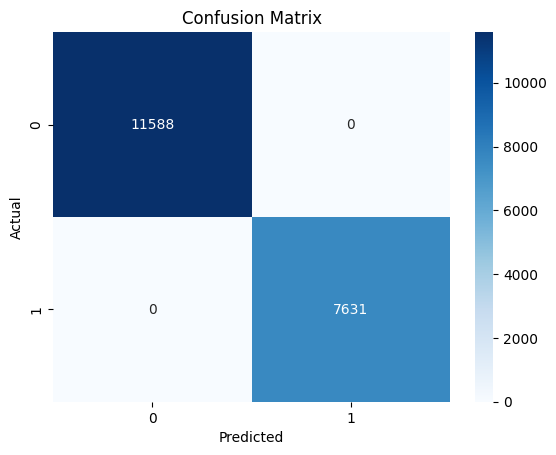

In [3]:

X = df[['total_spend', 'total_orders', 'days_since_last_order']]
y = df['churn_risk_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 3. Feature Importance

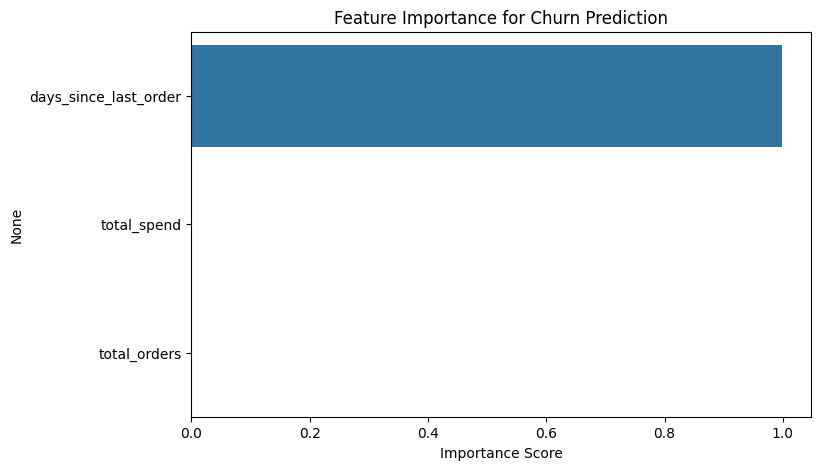

In [4]:

feature_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Feature Importance for Churn Prediction')
plt.xlabel('Importance Score')
plt.show()


## 4. Export Predictions to Database
We will save the test set predictions back to the data warehouse.

In [5]:

df_results = X_test.copy()
df_results['customer_id'] = df.loc[X_test.index, 'customer_id']
df_results['actual_churn_risk'] = y_test
df_results['predicted_churn_risk'] = y_pred

# Save to Postgres
print("Writing predictions to analytics.ml_churn_predictions...")
df_results.to_sql('ml_churn_predictions', engine, schema='analytics', if_exists='replace', index=False)
print("Done!")


Writing predictions to analytics.ml_churn_predictions...


Done!
